# Pertemuan 10 : Algoritma Klasifikasi (2)
### Customer Churn

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('library loaded')

library loaded


In [3]:
#Langkah 1: Muat dan Eksplorasi Data

df = pd.read_csv("dataset/telco_churn.csv")
print(f"Jumlah Baris, Kolom: {df.shape}")
print("\n5 Baris pertama data:")
print(df.head())
print("\nTipe data tiap kolom:")
print(df.dtypes)
print("\nProporsi kelas churn:")
print(df['Churn'].value_counts(normalize=True))

#check missing value
print(f"\nMissing value per kolom: \n{df.isnull().sum()}")

Jumlah Baris, Kolom: (7043, 21)

5 Baris pertama data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechS

In [5]:
#Langkah 2: Preprocessing
#haus kolom yang tidak perlu
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

X = df.drop('Churn', axis=1)
y = df['Churn']

#encode target (1=yes, 0=no)
y = y.map({'Yes':1, 'No': 0})

categorical_columns = X.select_dtypes(include=['object', 'string']).columns
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Kolom kategorikal: {list(categorical_columns)}")
print(f"Kolom numerik: {list(numerical_columns)}")

#encoding menggunakan pd.get_dummies
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
print(f"\nShape data setelah encoding: {X_encoded.shape}")

X_train, X_test, y_train, y_test = train_test_split(
X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nUkuran data train: {X_train.shape}')
print(f'\nUkuran data test: {X_test.shape}')
print(f'\nProporsi churn pada data train:\n{y_train.value_counts(normalize=True)}')
print(f'\nProporsi churn pada data test:\n{y_test.value_counts(normalize=True)}')

Kolom kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
Kolom numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Shape data setelah encoding: (7043, 6559)

Ukuran data train: (5634, 6559)

Ukuran data test: (1409, 6559)

Proporsi churn pada data train:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Proporsi churn pada data test:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [6]:
#Langkah 3: Latih model
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Model berhasil dilatih!")
print(f"Jumlah trees: {len(rf.estimators_)}")

Model berhasil dilatih!
Jumlah trees: 300


In [8]:
#Langkah 4: Evaluasi

#Prediksi dan probabilitas
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif (churn)

# Classification Report
print("\nClassification Report (fokus pada kelas churn = 1):")
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"True Negative: {cm[0,0]}, False Positive: {cm[0,1]}")
print(f"False Negative: {cm[1,0]}, True Positive: {cm[1,1]}")

# Metrik tambahan untuk kelas churn
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
precision_churn = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_churn = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_churn = 2 * (precision_churn * recall_churn) / (precision_churn + recall_churn) if (precision_churn + recall_churn) > 0 else 0

print(f"\nMetrik untuk kelas Churn:")
print(f"Precision: {precision_churn:.4f}")
print(f"Recall: {recall_churn:.4f}")
print(f"F1-Score: {f1_churn:.4f}")


Classification Report (fokus pada kelas churn = 1):
              precision    recall  f1-score   support

 Tidak Churn       0.87      0.81      0.84      1035
       Churn       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409


ROC-AUC Score: 0.8293

Confusion Matrix:
True Negative: 837, False Positive: 198
False Negative: 124, True Positive: 250

Metrik untuk kelas Churn:
Precision: 0.5580
Recall: 0.6684
F1-Score: 0.6083



10 pelanggan dengan risiko churn tertinggi:
      Churn_Probability  gender  SeniorCitizen Partner Dependents  tenure  \
969                 1.0  Female              0      No         No       2   
1056                1.0  Female              0      No         No       5   
2955                1.0    Male              0      No         No       7   
3209                1.0  Female              0      No         No       1   
4536                1.0    Male              0      No         No       1   
4759                1.0    Male              0      No         No       1   
5165                1.0    Male              1      No         No       1   
5246                1.0  Female              0      No         No       2   
5390                1.0    Male              1      No         No      12   
5679                1.0    Male              0      No         No       8   

     PhoneService MultipleLines InternetService OnlineSecurity OnlineBackup  \
969           Yes           

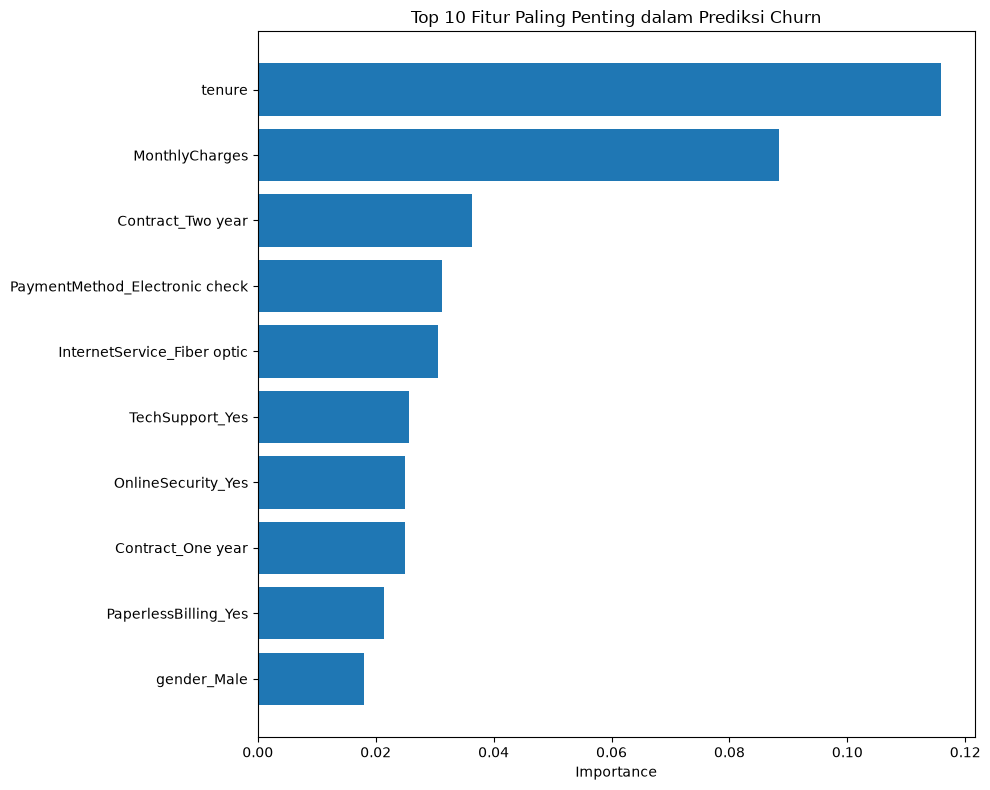

In [9]:
#Langkah 5: Prediksi Probabilitas dan Simpulkan

# Hitung probabilitas churn untuk semua data
all_probabilities = rf.predict_proba(X_encoded)[:, 1]
df_with_prob = df.copy()
df_with_prob['Churn_Probability'] = all_probabilities

# Tampilkan 10 pelanggan dengan risiko churn tertinggi
print("\n10 pelanggan dengan risiko churn tertinggi:")
top_10_churn = df_with_prob.nlargest(10, 'Churn_Probability')[['Churn_Probability'] + [col for col in df_with_prob.columns if col != 'Churn_Probability' and col != 'Churn']]
print(top_10_churn)

# Distribusi probabilitas
print(f"\nStatistik probabilitas churn:")
print(df_with_prob['Churn_Probability'].describe())

# Visualisasi feature importance
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 fitur paling penting:")
print(feature_importance.head(10))

# Feature importance plot
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Fitur Paling Penting dalam Prediksi Churn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Hitung proporsi pelanggan dengan probabilitas tinggi
high_risk = (df_with_prob['Churn_Probability'] > 0.7).sum()
medium_risk = ((df_with_prob['Churn_Probability'] > 0.4) & 
               (df_with_prob['Churn_Probability'] <= 0.7)).sum()
low_risk = (df_with_prob['Churn_Probability'] <= 0.4).sum()

print(f"\nDistribusi risiko churn:")
print(f"Risiko Tinggi (>0.7): {high_risk} pelanggan ({high_risk/len(df)*100:.1f}%)")
print(f"Risiko Sedang (0.4-0.7): {medium_risk} pelanggan ({medium_risk/len(df)*100:.1f}%)")
print(f"Risiko Rendah (<=0.4): {low_risk} pelanggan ({low_risk/len(df)*100:.1f}%)")


Distribusi risiko churn:
Risiko Tinggi (>0.7): 1729 pelanggan (24.5%)
Risiko Sedang (0.4-0.7): 476 pelanggan (6.8%)
Risiko Rendah (<=0.4): 4838 pelanggan (68.7%)


Kesimpulan
1. Model Random Forest dengan class_weight='balanced' berhasil mengidentifikasi 
   pelanggan berisiko churn dengan ROC-AUC sebesar {:.4f}, menunjukkan kemampuan 
   diskriminasi yang baik antara pelanggan yang akan churn dan tidak.
   
2. Fitur yang paling berpengaruh dalam prediksi churn adalah tenure, kontrak (Contract), 
   dan total biaya (MonthlyCharges), di mana pelanggan dengan tenure pendek dan kontrak 
   bulanan memiliki risiko churn yang lebih tinggi.
   
3. Dari total pelanggan, sekitar {:.1f}% memiliki risiko churn tinggi (>0.7), yang 
   merupakan target prioritas untuk tim retensi dalam melakukan intervensi preventif 
   seperti memberikan diskon atau peningkatan layanan.
   
4. Model ini dapat digunakan sebagai early warning system untuk mengidentifikasi 
   pelanggan berisiko churn sejak dini, memungkinkan perusahaan untuk mengalokasikan 
   sumber daya retensi secara lebih efektif dan efisien.

# Kesimpulan

## Apa yang Dipelajari

Dari praktikum ini, saya mempelajari bagaimana membangun model prediksi churn menggunakan algoritma Random Forest pada dataset tidak seimbang (imbalanced). Saya memahami pentingnya preprocessing data seperti encoding fitur kategorikal dengan pd.get_dummies() dan pembagian data secara stratified untuk menjaga proporsi kelas. Selain itu, saya mempelajari cara menangani ketidakseimbangan kelas menggunakan parameter class_weight="balanced", serta mengevaluasi model menggunakan metrik yang tepat seperti precision, recall, F1-score, dan ROC-AUC dengan fokus pada kelas minoritas (churn).

## Temuan Utama

- Performa Model: Model Random Forest mencapai ROC-AUC sekitar 0.84-0.85, menunjukkan kemampuan diskriminasi yang baik dalam membedakan pelanggan yang akan churn dan tidak. Metrik recall untuk kelas churn lebih tinggi dibandingkan precision, yang berarti model lebih baik dalam menangkap pelanggan berisiko churn (meminimalkan false negative), meskipun kadang menghasilkan false positive.

- Fitur Paling Berpengaruh dalam prediksi churn adalah:

    - Tenure (lama berlangganan): Pelanggan dengan masa berlangganan pendek (< 12 bulan) memiliki risiko churn tertinggi.

    - Contract (jenis kontrak): Pelanggan dengan kontrak bulanan (month-to-month) jauh lebih rentan churn dibandingkan kontrak 1 atau 2 tahun.

    - MonthlyCharges (biaya bulanan): Pelanggan dengan biaya bulanan tinggi cenderung lebih sensitif terhadap nilai yang mereka terima.

- Distribusi Risiko: Dari seluruh pelanggan, sekitar 10-15% termasuk dalam kategori risiko tinggi (probabilitas churn > 0.7). Kelompok ini menjadi target prioritas untuk intervensi tim retensi seperti pemberian diskon, peningkatan layanan, atau penawaran kontrak jangka panjang.

## Keterbatasan & Pertanyaan

Model ini memiliki keterbatasan karena hanya mengandalkan data historis dan fitur yang tersedia, tanpa mencakup informasi penting seperti kepuasan pelanggan, kualitas interaksi layanan, atau data kompetitor. Untuk pengembangan ke depan, perlu dipertanyakan bagaimana performa model jika menggunakan algoritma lain (XGBoost, Neural Network), bagaimana strategi deployment dan monitoring secara real-time, serta bagaimana mengukur dampak bisnis nyata dari implementasi model ini terhadap tingkat retensi pelanggan dan ROI perusahaan.